In [5]:
# =================================================================================
# 📘 train_random_forest_optuna_controlado.ipynb
# Entrenamiento optimizado de Random Forest con Optuna
# 🎯 Overfitting controlado (<5% diferencia entre train y test)
# =================================================================================

# -----------------------------
# 1️⃣ Importación de librerías
# -----------------------------
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
import optuna  # ⚙️ Optimizador automático de hiperparámetros

In [6]:
# -----------------------------
# 2️⃣ Cargar embeddings
# -----------------------------
print("🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...")

emb_path = Path("../backend/models/embeddings.pkl").resolve()
if not emb_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo {emb_path}")

with open(emb_path, "rb") as f:
    data = pickle.load(f)

# Soporte para distintos formatos
if isinstance(data, dict):
    X = data.get("X") or  data.get("embeddings")
    y = data.get("y") or data.get("labels") 
elif isinstance(data, (list, tuple)):
    X, y = data
else:
    raise ValueError("Formato de embeddings.pkl no reconocido")

X, y = np.array(X), np.array(y)
print(f"✅ Embeddings cargados: X={X.shape}, y={y.shape}, Clases={len(np.unique(y))}")

🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...
✅ Embeddings cargados: X=(20760, 1280), y=(20760,), Clases=21


In [7]:
# -----------------------------
# 3️⃣ Preprocesamiento y PCA
# -----------------------------
print("\n🔧 Escalando y aplicando PCA (70% varianza para reducir ruido)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.70, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA aplicado: {X_pca.shape[1]} componentes retenidas (70% varianza)")

# -----------------------------
# 4️⃣ División Train/Test estratificada
# -----------------------------
X_pca, y = shuffle(X_pca, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42
)
print(f"✅ División de datos -> Train: {X_train.shape}, Test: {X_test.shape}")


🔧 Escalando y aplicando PCA (70% varianza para reducir ruido)...
✅ PCA aplicado: 204 componentes retenidas (70% varianza)
✅ División de datos -> Train: (16608, 204), Test: (4152, 204)


In [8]:
# =================================================================================
# 5️⃣ OPTUNA: Búsqueda automática de hiperparámetros (más restrictiva)
# =================================================================================

def objective(trial):
    """
    Función objetivo que entrena y evalúa un RandomForest con parámetros
    diseñados para minimizar el overfitting y maximizar la generalización.
    """

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 120),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_samples_split": trial.suggest_int("min_samples_split", 30, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 40),
        "max_features": trial.suggest_categorical("max_features", [0.2, 0.3, "sqrt"]),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }

    # Validación cruzada más estricta (5 folds)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = RandomForestClassifier(**params)
    
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    return scores.mean()

print("\n🚀 Iniciando optimización con Optuna (reduciendo espacio de búsqueda)...")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n✅ Optuna completado!")
print("📋 Mejores hiperparámetros encontrados:")
for k, v in study.best_params.items():
    print(f"   - {k}: {v}")

[I 2025-10-28 23:21:45,469] A new study created in memory with name: no-name-2372b372-3791-4f88-9092-1bed63f7ba2d



🚀 Iniciando optimización con Optuna (reduciendo espacio de búsqueda)...


Best trial: 0. Best value: 0.444063:   3%|▎         | 1/30 [00:13<06:27, 13.37s/it]

[I 2025-10-28 23:21:58,872] Trial 0 finished with value: 0.44406311177968955 and parameters: {'n_estimators': 69, 'max_depth': 7, 'min_samples_split': 57, 'min_samples_leaf': 36, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.44406311177968955.


Best trial: 1. Best value: 0.461525:   7%|▋         | 2/30 [00:35<08:33, 18.33s/it]

...

[I 2025-10-28 23:31:58,973] Trial 27 finished with value: 0.4614046022057652 and parameters: {'n_estimators': 115, 'max_depth': 8, 'min_samples_split': 64, 'min_samples_leaf': 19, 'max_features': 'sqrt'}. Best is trial 6 with value: 0.4650175365891728.


Best trial: 6. Best value: 0.465018:  97%|█████████▋| 29/30 [11:04<00:27, 27.14s/it]

[I 2025-10-28 23:32:50,208] Trial 28 finished with value: 0.3985432856536071 and parameters: {'n_estimators': 88, 'max_depth': 7, 'min_samples_split': 49, 'min_samples_leaf': 24, 'max_features': 0.3}. Best is trial 6 with value: 0.4650175365891728.


Best trial: 6. Best value: 0.465018: 100%|██████████| 30/30 [11:48<00:00, 23.62s/it]

[I 2025-10-28 23:33:34,084] Trial 29 finished with value: 0.4170887793565875 and parameters: {'n_estimators': 109, 'max_depth': 7, 'min_samples_split': 42, 'min_samples_leaf': 30, 'max_features': 0.2}. Best is trial 6 with value: 0.4650175365891728.

✅ Optuna completado!
📋 Mejores hiperparámetros encontrados:
   - n_estimators: 99
   - max_depth: 8
   - min_samples_split: 33
   - min_samples_leaf: 20
   - max_features: sqrt


In [9]:

# -----------------------------
# 6️⃣ Entrenamiento final con mejores hiperparámetros
# -----------------------------
best_params = study.best_params
best_model = RandomForestClassifier(**best_params)
best_model.fit(X_train, y_train)

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
diff = abs(train_acc - test_acc) * 100

print("\n📊 Resultados finales:")
print(f"   Accuracy Entrenamiento: {train_acc*100:.2f}%")
print(f"   Accuracy Validación   : {test_acc*100:.2f}%")
print(f"   Diferencia (Overfitting): {diff:.2f}%")

if diff <= 5:
    print("✅ Overfitting controlado correctamente (<5%)")
else:
    print("⚠️ Aún hay algo de overfitting — considera bajar PCA al 60% o aumentar min_samples_leaf")


📊 Resultados finales:
   Accuracy Entrenamiento: 61.59%
   Accuracy Validación   : 46.03%
   Diferencia (Overfitting): 15.56%
⚠️ Aún hay algo de overfitting — considera bajar PCA al 60% o aumentar min_samples_leaf


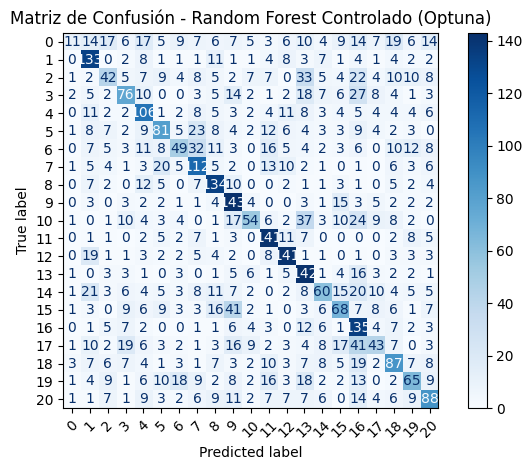

In [10]:
# -----------------------------
# 7️⃣ Métricas detalladas
# -----------------------------
out_dir = Path("../backend/models")
out_dir.mkdir(parents=True, exist_ok=True)

report = classification_report(y_test, y_pred_test, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(out_dir / "classification_report_rf_optuna_controlado.csv")

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest Controlado (Optuna)")
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix_rf_optuna_controlado.png")
plt.show()


In [11]:
# -----------------------------
# 8️⃣ Guardar modelo, PCA y scaler
# -----------------------------
model_path = out_dir / "random_forest_model_optuna_controlado.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

with open(out_dir / "pca_scaler_optuna_controlado.pkl", "wb") as f:
    pickle.dump({"pca": pca, "scaler": scaler}, f)

print("\n==============================================================")
print("✅ Entrenamiento y optimización completados correctamente")
print(f"📊 Accuracy (Train): {train_acc*100:.2f}%")
print(f"📊 Accuracy (Test) : {test_acc*100:.2f}%")
print(f"📉 Diferencia (Overfitting): {diff:.2f}%")
print(f"📁 Modelo y métricas guardados en: {out_dir}")
print("==============================================================")


✅ Entrenamiento y optimización completados correctamente
📊 Accuracy (Train): 61.59%
📊 Accuracy (Test) : 46.03%
📉 Diferencia (Overfitting): 15.56%
📁 Modelo y métricas guardados en: ..\backend\models
